# Generate mock analytics data

This notebook creates synthetic usage data for the business dashboard.

The data represents simulated parent searches and venue activity. It is intended only for demonstrating the MVP and does not represent real users or confirmed customer behaviour.

In [129]:
%pip install -q pandas numpy matplotlib requests

import json
import os
import random
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

random.seed(42)
np.random.seed(42)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Set a random seed

A fixed random seed ensures that the notebook generates the same demo data each time it is run.

## Configure the mock dataset

The mock dataset will cover the previous 60 days.

The IDs below must correspond to records in the development database. The current seeded database contains parent users with IDs 2 and 3, five sample venues and ten amenities.

In [130]:
API_URL = os.getenv("API_URL", "http://4.223.159.135").rstrip("/")

NUMBER_OF_SEARCHES = 300
NUMBER_OF_DAYS = 60
NUMBER_OF_VIEWS = 180
NUMBER_OF_DEMO_VENUES = 10

USER_IDS = [2, 3]
CATEGORIES = [
    "catering.cafe",
    "catering.restaurant",
    "entertainment.museum",
    "leisure.playground",
]

MOCK_OUTPUT_DIR = Path("data/mock")
MOCK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

explicit_frontend_dir = os.getenv("FRONTEND_ANALYTICS_DIR")

if explicit_frontend_dir:
    DASHBOARD_OUTPUT_DIR = Path(explicit_frontend_dir)
else:
    candidates = [
        Path("../child-and-me-frontend/public/analytics"),
        Path("../project-delta-frontend/public/analytics"),
        Path("../Project-Delta-dev/public/analytics"),
    ]
    DASHBOARD_OUTPUT_DIR = next(
        (p for p in candidates if p.parent.parent.exists()),
        Path("data/charts")
    )

DASHBOARD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("API:", API_URL)
print("Dashboard output:", DASHBOARD_OUTPUT_DIR.resolve())


API: http://4.223.159.135
Dashboard output: C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts


In [131]:
def get_json(path):
    response = requests.get(f"{API_URL}{path}", timeout=30)
    response.raise_for_status()
    return response.json()

venues_df = pd.DataFrame(get_json("/venues"))
amenities_df = pd.DataFrame(get_json("/amenities"))
venue_amenities_df = pd.DataFrame(get_json("/venueAmenities"))

required_venue_columns = {"id", "name", "category", "latitude", "longitude"}
missing = required_venue_columns - set(venues_df.columns)
if missing:
    raise ValueError(f"/venues is missing columns: {sorted(missing)}")

if amenities_df.empty:
    raise ValueError("No amenities were returned by /amenities")

venues_df["latitude"] = pd.to_numeric(venues_df["latitude"], errors="coerce")
venues_df["longitude"] = pd.to_numeric(venues_df["longitude"], errors="coerce")
venues_df = venues_df.dropna(subset=["id", "name", "latitude", "longitude"]).copy()

if "category" not in venues_df:
    venues_df["category"] = None

print(f"{len(venues_df)} venues loaded")
print(f"{len(amenities_df)} amenities loaded")
print(f"{len(venue_amenities_df)} venue-amenity relationships loaded")

display(venues_df[["id", "name", "category", "latitude", "longitude"]].head())
display(amenities_df[["id", "name"]])


318 venues loaded
10 amenities loaded
1772 venue-amenity relationships loaded


,id,name,category,latitude,longitude
0,1,Caffè Nero,vegetarian,51.507277,-0.128365
1,2,Caffe Concerto,wheelchair.limited,51.507116,-0.126693
2,3,Costa,wheelchair.yes,51.507501,-0.126768
3,4,The Grand Caffè,catering.cafe,51.507816,-0.126517
4,5,Costa,wheelchair.yes,51.508033,-0.125299


,id,name
0,1,Accessible entrance
1,2,Accessible toilet
2,7,Breastfeeding friendly
3,5,Changing facilities
4,8,Children's activities
5,10,High chairs
6,9,Parking
7,3,Prams allowed
8,4,Pram storage
9,6,Table reservation


In [132]:
eligible_venues = venues_df[
    venues_df["category"].isin(CATEGORIES)
].copy()

if eligible_venues.empty:
    eligible_venues = venues_df.copy()

demo_venues_df = eligible_venues.sample(
    n=min(NUMBER_OF_DEMO_VENUES, len(eligible_venues)),
    random_state=42
).copy()

venue_ids = demo_venues_df["id"].astype(int).tolist()
amenity_ids = amenities_df["id"].astype(int).tolist()
amenity_names = dict(zip(
    amenities_df["id"].astype(int),
    amenities_df["name"]
))

display(demo_venues_df[["id", "name", "category"]])


,id,name,category
260,261,People's Museum Somers Town,entertainment.museum
24,25,St. George London,catering.cafe
14,15,Blue Onion,catering.cafe
279,280,RIBA Architecture Study Rooms,entertainment.museum
198,199,Petit Bistro,catering.restaurant
220,221,Twist Museum,entertainment.museum
99,100,Honeymoon Dessert 满记甜品,catering.cafe
141,142,Ristorante Roma,catering.restaurant
305,306,Small Playground,leisure.playground
25,26,Pavilion Cafe,catering.cafe


## Generate mock search events

Each record represents a parent searching the app.

Searches are given a simulated user, date and time, location, category and number of results. The generated coordinates are located approximately around Hertfordshire.

In [133]:
search_events = []
end_date = datetime.now()
start_date = end_date - timedelta(days=NUMBER_OF_DAYS)

for search_id in range(1, NUMBER_OF_SEARCHES + 1):
    anchor = demo_venues_df.sample(n=1).iloc[0]

    # Roughly a few hundred metres to a few kilometres around a real venue.
    lat_offset = np.random.normal(0, 0.008)
    lon_offset = np.random.normal(0, 0.012)

    category = anchor["category"]
    if pd.isna(category) or category not in CATEGORIES:
        category = random.choice(CATEGORIES)

    searched_at = start_date + timedelta(
        seconds=random.randint(
            0,
            max(1, int((end_date - start_date).total_seconds()))
        )
    )

    search_events.append({
        "id": search_id,
        "user_id": random.choice(USER_IDS),
        "latitude": float(anchor["latitude"]) + float(lat_offset),
        "longitude": float(anchor["longitude"]) + float(lon_offset),
        "radius": random.choice([1000, 2500, 5000, 10000]),
        "category": category,
        "result_count": random.randint(0, 30),
        "searched_at": searched_at,
    })

search_events_df = pd.DataFrame(search_events)
search_events_df.head()


,id,user_id,latitude,longitude,radius,category,result_count,searched_at
0,1,2,51.499975,-0.098727,5000,leisure.playground,7,2026-08-10 09:27:27.213346
1,2,2,51.527337,-0.136537,1000,entertainment.museum,21,2026-08-21 06:09:22.213346
2,3,2,51.506436,-0.135958,10000,catering.cafe,1,2026-09-21 12:50:01.213346
3,4,2,51.507513,-0.127407,2500,catering.cafe,7,2026-08-02 11:28:12.213346
4,5,2,51.511423,-0.145878,2500,catering.cafe,22,2026-09-17 15:36:02.213346


## Review the mock search data

The date range and category counts are checked to ensure that the generated dataset is suitable for the dashboard.

In [134]:
print("First date:", search_events_df["searched_at"].min())
print("Last date:", search_events_df["searched_at"].max())

display(
    search_events_df["category"].value_counts()
)

First date: 2026-07-30 20:00:53.213346
Last date: 2026-09-27 20:12:48.213346


category
catering.cafe           118
entertainment.museum     87
catering.restaurant      55
leisure.playground       40
Name: count, dtype: int64

## Generate requested amenities

Each search will include between one and three requested amenities.

The amenities are weighted so that family-focused facilities such as changing facilities, pram access and high chairs appear more frequently. This creates realistic patterns for the demonstration dashboard.

In [135]:
amenity_weight_by_name = {
    "Accessible entrance": 10,
    "Accessible toilet": 14,
    "Prams allowed": 22,
    "Pram storage": 12,
    "Changing facilities": 28,
    "Table reservation": 8,
    "Breastfeeding friendly": 18,
    "Children's activities": 16,
    "Parking": 12,
    "High chairs": 20,
}

weighted_amenity_ids = []
for amenity_id in amenity_ids:
    name = amenity_names.get(amenity_id, "")
    weight = amenity_weight_by_name.get(name, 10)
    weighted_amenity_ids.extend([amenity_id] * weight)

search_event_amenities = []

for search_id in search_events_df["id"]:
    requested_count = random.randint(1, min(3, len(amenity_ids)))

    selected = set()
    while len(selected) < requested_count:
        selected.add(random.choice(weighted_amenity_ids))

    for amenity_id in selected:
        search_event_amenities.append({
            "search_event_id": int(search_id),
            "amenity_id": int(amenity_id),
        })

search_event_amenities_df = pd.DataFrame(search_event_amenities)

amenity_demand = (
    search_event_amenities_df
    .groupby("amenity_id")
    .size()
    .reset_index(name="search_count")
)

amenity_demand["amenity_name"] = amenity_demand["amenity_id"].map(amenity_names)
amenity_demand = amenity_demand.sort_values("search_count", ascending=False)

display(amenity_demand)


,amenity_id,search_count,amenity_name
4,5,79,Changing facilities
6,7,77,Breastfeeding friendly
9,10,75,High chairs
7,8,71,Children's activities
2,3,70,Prams allowed
1,2,65,Accessible toilet
8,9,63,Parking
3,4,49,Pram storage
0,1,32,Accessible entrance
5,6,31,Table reservation


In [136]:
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

search_side = search_events_df[
    ["id", "latitude", "longitude", "radius", "category", "searched_at"]
].rename(columns={
    "id": "search_event_id",
    "latitude": "search_latitude",
    "longitude": "search_longitude",
    "category": "search_category",
})

venue_side = demo_venues_df[
    ["id", "name", "latitude", "longitude", "category"]
].rename(columns={
    "id": "venue_id",
    "name": "venue_name",
    "latitude": "venue_latitude",
    "longitude": "venue_longitude",
    "category": "venue_category",
})

nearby = search_side.merge(venue_side, how="cross")

nearby["distance_km"] = haversine_km(
    nearby["search_latitude"],
    nearby["search_longitude"],
    nearby["venue_latitude"],
    nearby["venue_longitude"],
)

nearby["radius_km"] = nearby["radius"] / 1000

nearby_searches = nearby[
    (nearby["distance_km"] <= nearby["radius_km"])
    & (nearby["search_category"] == nearby["venue_category"])
].copy()

nearby_search_counts = (
    nearby_searches
    .groupby(["venue_id", "venue_name"])
    ["search_event_id"]
    .nunique()
    .reset_index(name="nearby_searches")
)

display(nearby_search_counts.sort_values("nearby_searches", ascending=False))


,venue_id,venue_name,nearby_searches
1,25,St. George London,98
3,100,Honeymoon Dessert 满记甜品,98
0,15,Blue Onion,96
2,26,Pavilion Cafe,96
6,221,Twist Museum,60
7,261,People's Museum Somers Town,59
8,280,RIBA Architecture Study Rooms,59
4,142,Ristorante Roma,51
5,199,Petit Bistro,51
9,306,Small Playground,35


In [137]:
views_by_venue = (
    venue_views_df
    .groupby("venue_id")
    .size()
    .reset_index(name="views")
    .merge(
        demo_venues_df[["id", "name"]],
        left_on="venue_id",
        right_on="id",
        how="left"
    )
    .drop(columns=["id"])
)

display(views_by_venue.sort_values("views", ascending=False))


,venue_id,views,name
0,1,49,NaN
1,2,44,NaN
3,4,33,NaN
2,3,26,NaN
4,5,14,NaN
9,199,4,Petit Bistro
5,25,2,St. George London
7,100,2,Honeymoon Dessert 满记甜品
8,142,2,Ristorante Roma
10,221,2,Twist Museum


In [138]:
nearby_requests = (
    nearby_searches[
        ["venue_id", "venue_name", "search_event_id"]
    ]
    .merge(
        search_event_amenities_df,
        on="search_event_id",
        how="inner"
    )
)

amenity_counts = (
    nearby_requests
    .groupby(["venue_id", "venue_name", "amenity_id"])
    .size()
    .reset_index(name="request_count")
)

amenity_counts["amenity_name"] = amenity_counts["amenity_id"].map(amenity_names)

display(
    amenity_counts
    .sort_values(["venue_id", "request_count"], ascending=[True, False])
    .head(30)
)


,venue_id,venue_name,amenity_id,request_count,amenity_name
2,15,Blue Onion,3,28,Prams allowed
7,15,Blue Onion,8,26,Children's activities
4,15,Blue Onion,5,25,Changing facilities
3,15,Blue Onion,4,21,Pram storage
8,15,Blue Onion,9,20,Parking
6,15,Blue Onion,7,19,Breastfeeding friendly
9,15,Blue Onion,10,19,High chairs
1,15,Blue Onion,2,17,Accessible toilet
0,15,Blue Onion,1,10,Accessible entrance
5,15,Blue Onion,6,10,Table reservation


In [139]:
if venue_amenities_df.empty:
    venue_amenities_df = pd.DataFrame(columns=["venue_id", "amenity_id"])

venue_amenities_df["venue_id"] = pd.to_numeric(
    venue_amenities_df["venue_id"], errors="coerce"
)
venue_amenities_df["amenity_id"] = pd.to_numeric(
    venue_amenities_df["amenity_id"], errors="coerce"
)

recorded_pairs = set(
    zip(
        venue_amenities_df["venue_id"].dropna().astype(int),
        venue_amenities_df["amenity_id"].dropna().astype(int),
    )
)

gaps = amenity_counts.copy()
gaps["recorded_for_venue"] = gaps.apply(
    lambda row: (
        int(row["venue_id"]),
        int(row["amenity_id"])
    ) in recorded_pairs,
    axis=1
)

gaps = gaps[~gaps["recorded_for_venue"]].copy()
gaps = gaps.sort_values(
    ["venue_id", "request_count"],
    ascending=[True, False]
)

display(gaps.head(30))


,venue_id,venue_name,amenity_id,request_count,amenity_name,recorded_for_venue
7,15,Blue Onion,8,26,Children's activities,False
8,15,Blue Onion,9,20,Parking,False
14,25,St. George London,5,27,Changing facilities,False
24,26,Pavilion Cafe,5,25,Changing facilities,False
26,26,Pavilion Cafe,7,20,Breastfeeding friendly,False
28,26,Pavilion Cafe,9,19,Parking,False
29,26,Pavilion Cafe,10,19,High chairs,False
49,142,Ristorante Roma,10,14,High chairs,False
48,142,Ristorante Roma,9,8,Parking,False
51,199,Petit Bistro,2,15,Accessible toilet,False


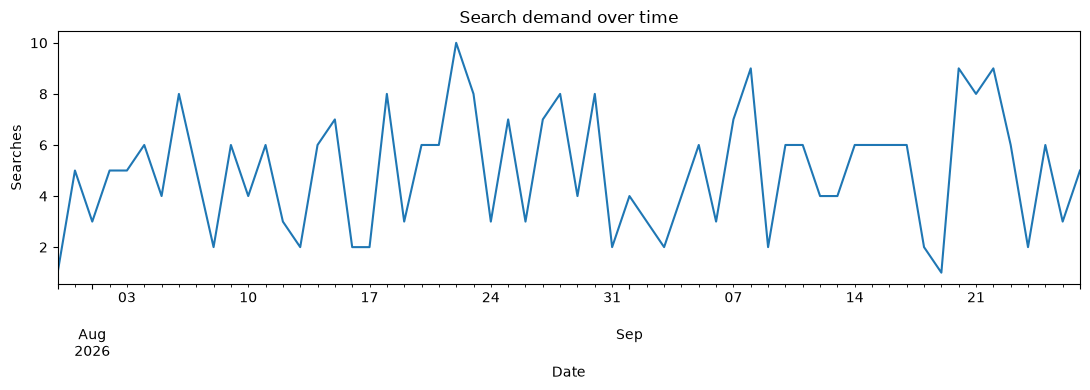

In [140]:
# 1. Search demand over time
search_demand_by_day = (
    search_events_df
    .assign(
        day=pd.to_datetime(search_events_df["searched_at"]).dt.floor("D")
    )
    .groupby("day")
    .size()
    .rename("searches")
)

ax = search_demand_by_day.plot(
    figsize=(11, 4),
    title="Search demand over time"
)
ax.set(xlabel="Date", ylabel="Searches")
plt.tight_layout()
plt.savefig(
    DASHBOARD_OUTPUT_DIR / "search-demand.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


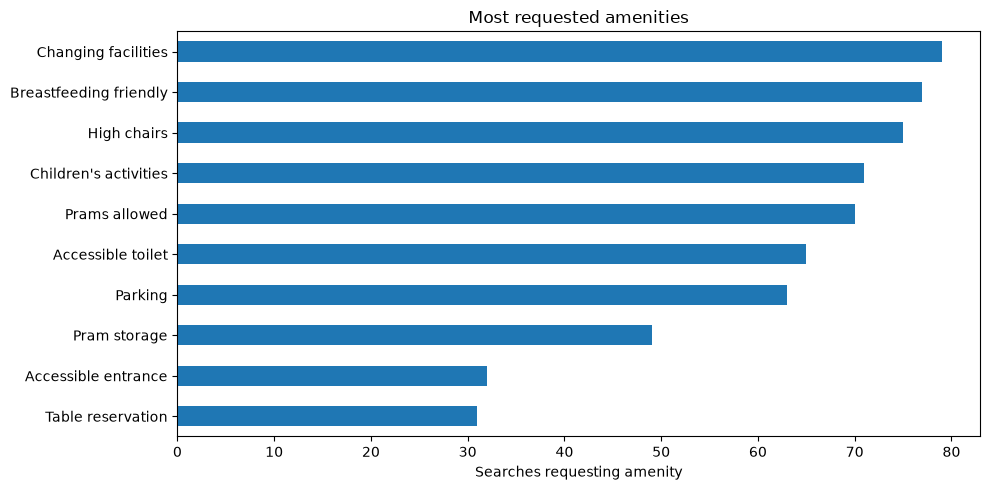

In [141]:
# 2. Most requested amenities
top_amenities = (
    amenity_demand
    .head(10)
    .sort_values("search_count")
)

ax = top_amenities.plot.barh(
    x="amenity_name",
    y="search_count",
    figsize=(10, 5),
    legend=False,
    title="Most requested amenities"
)
ax.set(xlabel="Searches requesting amenity", ylabel="")
plt.tight_layout()
plt.savefig(
    DASHBOARD_OUTPUT_DIR / "amenity-demand.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


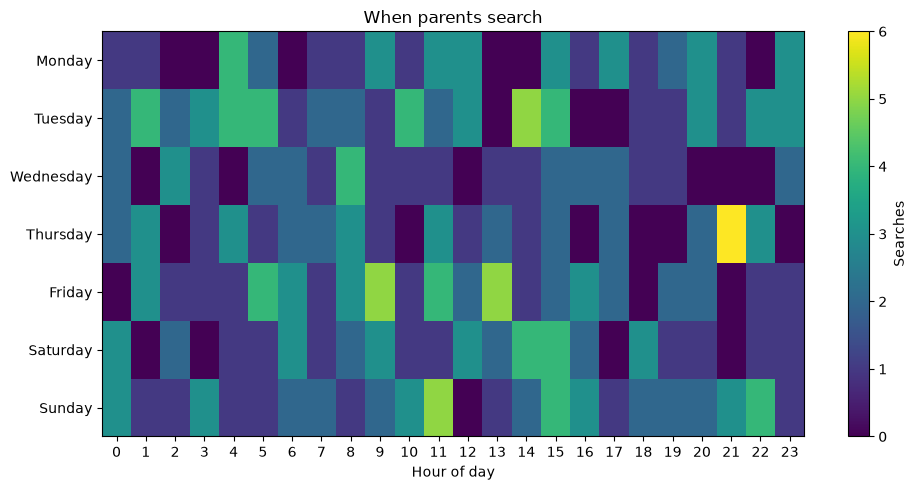

In [142]:
# 3. When parents search — day/hour heatmap
search_times_df = search_events_df.copy()
search_times_df["searched_at"] = pd.to_datetime(search_times_df["searched_at"])
search_times_df["day"] = search_times_df["searched_at"].dt.day_name()
search_times_df["hour"] = search_times_df["searched_at"].dt.hour

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

heatmap_data = pd.crosstab(
    search_times_df["day"],
    search_times_df["hour"]
).reindex(day_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
ax.set_title("When parents search")

fig.colorbar(image, ax=ax, label="Searches")
plt.tight_layout()
plt.savefig(
    DASHBOARD_OUTPUT_DIR / "search-heatmap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


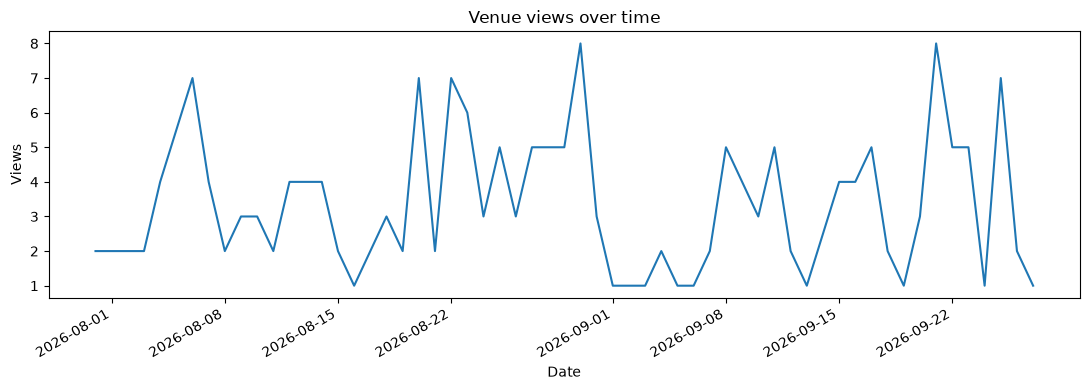

In [143]:
# 4. Venue views over time
views_over_time = (
    venue_views_df
    .assign(
        day=pd.to_datetime(venue_views_df["viewed_at"]).dt.floor("D")
    )
    .groupby("day")
    .size()
    .rename("views")
)

ax = views_over_time.plot(
    figsize=(11, 4),
    title="Venue views over time"
)
ax.set(xlabel="Date", ylabel="Views")
plt.tight_layout()
plt.savefig(
    DASHBOARD_OUTPUT_DIR / "venue-views-over-time.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## Export dashboard JSON

In [144]:
venue_summary = (
    demo_venues_df[["id", "name"]]
    .rename(columns={"id": "venue_id"})
    .merge(
        nearby_search_counts[["venue_id", "nearby_searches"]],
        on="venue_id",
        how="left"
    )
    .merge(
        views_by_venue[["venue_id", "views"]],
        on="venue_id",
        how="left"
    )
)

venue_summary[["nearby_searches", "views"]] = (
    venue_summary[["nearby_searches", "views"]]
    .fillna(0)
    .astype(int)
)

dashboard_data = {
    "generated_at": datetime.now().isoformat(),
    "is_demo_data": True,
    "venues": []
}

for _, venue in demo_venues_df.iterrows():
    venue_id = int(venue["id"])

    summary = venue_summary[
        venue_summary["venue_id"] == venue_id
    ].iloc[0]

    venue_requests = amenity_counts[
        amenity_counts["venue_id"] == venue_id
    ].sort_values("request_count", ascending=False)

    venue_gaps = gaps[
        gaps["venue_id"] == venue_id
    ].sort_values("request_count", ascending=False)

    current_ids = venue_amenities_df.loc[
        venue_amenities_df["venue_id"] == venue_id,
        "amenity_id"
    ].dropna().astype(int).tolist()

    current_amenities = [
        {
            "amenity_id": amenity_id,
            "name": amenity_names.get(amenity_id, str(amenity_id))
        }
        for amenity_id in current_ids
    ]

    dashboard_data["venues"].append({
        "venue_id": venue_id,
        "name": venue["name"],
        "views": int(summary["views"]),
        "relevant_searches": int(summary["nearby_searches"]),
        "venue_amenities": current_amenities,
        "amenity_demand": [
            {
                "amenity_id": int(row["amenity_id"]),
                "name": row["amenity_name"],
                "searches": int(row["request_count"]),
            }
            for _, row in venue_requests.iterrows()
        ],
        "opportunities": [
            {
                "amenity_id": int(row["amenity_id"]),
                "name": row["amenity_name"],
                "searches": int(row["request_count"]),
            }
            for _, row in venue_gaps.iterrows()
        ],
    })

json_path = DASHBOARD_OUTPUT_DIR / "business-analytics.json"

with json_path.open("w", encoding="utf-8") as f:
    json.dump(
        dashboard_data,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Dashboard outputs written to:")
for filename in [
    "search-demand.png",
    "amenity-demand.png",
    "search-heatmap.png",
    "venue-views-over-time.png",
    "business-analytics.json",
]:
    print(" -", (DASHBOARD_OUTPUT_DIR / filename).resolve())


Dashboard outputs written to:
 - C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts\search-demand.png
 - C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts\amenity-demand.png
 - C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts\search-heatmap.png
 - C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts\venue-views-over-time.png
 - C:\Users\yonat\La Fosse training\Projects\final-project\child-and-me-backend\data\scripts\data\charts\business-analytics.json


# End